<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/banner_IA.png"  width="1000px" height="200px">


# Taller 4: Algoritmos Genéticos: Knapsack Problem

## <span style="color:red"> Outline </span>

1. [Ejercicio 1. Función de inicialización](#eje1)
2. [Ejercicio 2. Función de coste](#eje2)
3. [Ejercicio 3. Función de mutación](#eje3)

In [ ]:
#@title **Execute this cell**
#@markdown Please include your student id
import sys
import inspect

group_id = "IA1-20251-B1" #@param {type:"string"}
assignment_id = group_id +'.taller_ga'
student_id = "2238327" #@param {type:"string"}
"""
Put your student ID here

Example: student_id =  '2152145'
"""

"\nPut your student ID here\n\nExample: student_id =  '2152145'\n"

In [ ]:
 #@title **Execute this cell**
#@markdown **UTILS**
#@markdown Please dont modify any line in this cell

import os
import json
import requests
from collections import namedtuple


Config = namedtuple('Config', ['server_name'])
config = Config(server_name='https://bivlabgrader.azurewebsites.net/api')


def check_solution_and_evaluate(assignment_id: str, student_func_str: str):

    # Set the endpoint and payload.
    payload = {
        'func_str': student_func_str,
        'assignment_id': assignment_id,
        'student_id': student_id
    }
    endpoint_url = config.server_name + '/CheckAndEvaluateSolution'
    # print(endpoint_url)

    # Make request to server with the data coming from the notebook.
    r = requests.post(endpoint_url, params=payload)
    pprint_json_response(r.json())
    return r


def pprint_json_response(response, indent=0):
    """Pretty print the response."""
    for key, value in response.items():
        print('\t' * indent + str(key.capitalize()))

        # If dictionary, do a recurrent call.
        if isinstance(value, dict):
            pprint_json_response(value, indent + 1)
        else:
            # Enumerate elements if list.
            if isinstance(value, list):
                if len(value) == 1:
                    print('\t' * (indent + 1) + str(value[0]))
                else:
                    for i, e in enumerate(value, start=1):
                        print('\t' * (indent + 1) + f'{i}. {e}')
            else:
                print('\t' * (indent + 1) + str(value))

In [ ]:
#@title **Execute this cell**
#@markdown Please dont modify any line in this cell

import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline

### Es hora de resolver el **problema de la mochila** utilizando algoritmos genéticos 🌝

<img src='https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/ks.jpg' style="width:700px;" align="center">


Tenemos $n$ objectos numerados del $0$ a $n-1$, con un tamaño $s_i$ y valor $v_i$ cada uno. Una solución cualquiera del problema es el vector $X=[x_0, x_2, ..., x_i, ... x_{n-1}]$, en donde $x_i \in \{0,1\}$ indica si el objecto $i$ se incluye o no la mochila. Como la mochila tiene un volumen máximo, $KS_{vol}$ el problema se formula de la siguiente manera:

$$ maximize \; X \;\; \sum_{i=0}^{n-1} x_i v_i$$

$$subject \; to \;\; \sum_{i=0}^{n-1} x_i s_i \le KS_{vol}$$

El vector $S=[s_0, s_2, ..., s_i, ... s_{n-1}]$ representa los tamaños de todos los objectos y el vector $V=[v_0, v_2, ..., v_i, ... v_{n-1}]$, los valores.

Fíjate a continuación cómo:

- Generamos vectores $S$ y $V$ aleatorios 🎒
- Generamos soluciones aleatorias 📊
- Verificamos si las soluciones generadas son válidas ✅


## **Ejercicio 1:** Inicialización de la población <a name="eje1"></a>

Crea una función para crear una población de soluciones aleatorias, teniendo en cuenta que:

- **TODAS LAS SOLUCIONES HAN DE SER VÁLIDAS**.
- Si crean soluciones aleatorias y las descartas si no son válidas seguramente tu código tarde mucho en generar la población si la probablidad de que una solución aleatoria sea válida es muy pequeña
- Tu código ha de devolver un array numpy de números enteros

Ejecución de ejemplo

    n_objects         = 20
    KS_volume         = 50
    n_individuals     = 10
    pop = KS_initialize_population(n_individuals, object_volumes, KS_volume)
    print pop

Salida esperada (la población es aleatoria, por tanto, tu salida probablemente sea distinta)

      [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


In [ ]:
#@title **code student**
def KS_initialize_population(n_individuals, object_volumes, KS_volume):
    import numpy as np

    return np.array(r)

Verifica tu código

In [ ]:
#@title **check your answer**


n_objects         = 50
max_object_value  = 100
max_object_volume = 50
KS_volume         = 50

n_individuals     = 100

object_values  = np.random.randint(max_object_value-1, size=n_objects)+1
object_volumes = np.random.randint(max_object_volume-1, size=n_objects)+1

def KS_isvalid(solution, object_volumes, KS_volume):
    return np.sum(solution*object_volumes)<=KS_volume

pop = KS_initialize_population(n_individuals, object_volumes, KS_volume)

n_invalid = int(np.sum([1 for i in pop if not KS_isvalid(i, object_volumes, KS_volume)]))

print( "Hay", n_invalid, "soluciones inválidas de un total de", len(pop), "soluciones")

Hay 0 soluciones inválidas de un total de 100 soluciones


In [ ]:
#@title **send your answer**
student_func_str = inspect.getsource(KS_initialize_population)
r = check_solution_and_evaluate(assignment_id, student_func_str)

Score
	5
Message
	✅ ¡Correcto!.
Status
	You have achieved your best score: 5


## **Ejercicio 2:** Función de coste <a name="eje2"></a>

El valor máximo que tendríamos si pudiéramos incluir todos los objetos en la mochila sería $V_{max}=\sum v_i$. El volumen de los objetos incluidos en una solución $X$ es $S(X)=\sum s_i x_i$. El valor de todos los objetos incluidos en una solución es $V(X)=\sum v_i x_i$

Crea una función de coste de manera que valores altos de las combinaciones de objetos representen un coste bajo, siempre y cuando no excedan la capacidad de la mochila. Observa que nuestra implementación de GA **MINIMIZA** un coste y nosotros queremos **MAXIMIZAR** un valor.


$$    KS\_cost(X)=\left\{
                \begin{array}{ll}
                  V_{max} - V(X) & si \;\; S(X) \le KS_{vol}\\
                  V_{max} & si \;\; S(X) \gt KS_{vol}\\
                \end{array}
              \right.
$$

In [ ]:
#@title **Code student**
def KS_cost(solution, object_values, object_volumes, KS_volume):
    import numpy as np
    max_value = None
    return None

Comprueba tu código. La gráfica generada tiene que tener aproximadamente la siguiente forma:
<img src='https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/kscost.jpg' style="width:500px;">

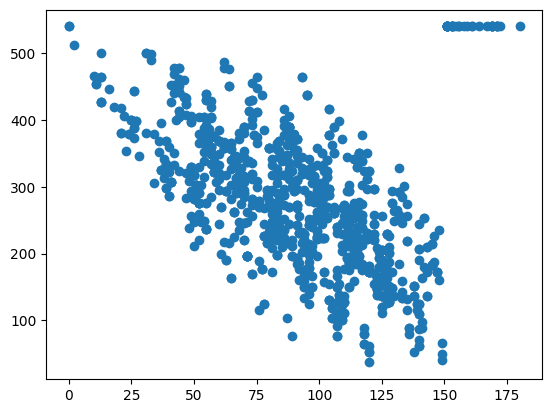

In [ ]:
#@title **Check your answer**

n_objects         = 10
max_object_value  = 100
max_object_volume = 40
KS_volume         = 150

n_individuals     = 1000

object_values  = np.random.randint(max_object_value-1, size=n_objects)+1
object_volumes = np.random.randint(max_object_volume-1, size=n_objects)+1

pop = KS_initialize_population(n_individuals, object_volumes, KS_volume)

pop = np.random.randint(2, size=(n_individuals, len(object_volumes)))

vols = [np.sum(i*object_volumes) for i in pop]
costs = [KS_cost(i, object_values, object_volumes, KS_volume) for i in pop]

plt.scatter(vols, costs)

In [ ]:
#@title **Send your answer**
student_func_str = inspect.getsource(KS_cost)
r = check_solution_and_evaluate(assignment_id, student_func_str)

Score
	5
Message
	✅ ¡Correcto!.
Status
	You have achieved your best score: 5


## **Ejercicio 3:** Función de mutación <a name="eje3"></a>

Crea una función de mutación que, con probabilidad $mutation\_prob$ genere una mutación **VALIDA** de un bit de una solución.

Ejemplo de ejecución:

    sol = np.array([0 0 0 0 1 0 1 1 0 0])
    print KS_mutate(pop[1], 0.9, object_volumes, KS_volume)
    
Salida esperada (sujeto a procesos aleatorios):

    > [0 0 0 0 1 0 1 0 0 0]

In [ ]:
#@title **Code student**
def KS_mutate():
    import numpy as np
    import random

    return solution

In [ ]:
#@title **Check your answer**
object_values  = np.array([22, 19, 49, 32, 66, 86, 51, 94, 33, 33])
object_volumes = np.array([ 6, 36,  8, 14, 12, 19, 27,  4, 15,  4])
KS_volume      = 150

pop  = np.array([[0, 1, 1, 0, 0, 1, 0, 1, 0, 1],
                 [1, 1, 0, 1, 1, 0, 0, 1, 1, 1],
                 [1, 0, 0, 1, 1, 1, 1, 0, 0, 1],
                 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
mutation_prob     = 0.1

print( "original              mutada                diferencia")
for i in pop:
    m = KS_mutate(i, mutation_prob, object_volumes, KS_volume)
    print( m, i, np.sum((m-i)**2))

original              mutada                diferencia
[0 1 1 0 0 1 0 1 0 1] [0 1 1 0 0 1 0 1 0 1] 0
[1 1 0 1 1 0 0 1 1 1] [1 1 0 1 1 0 0 1 1 1] 0
[1 0 0 1 1 1 1 0 0 1] [1 0 0 1 1 1 1 0 0 1] 0
[0 1 0 0 0 0 0 0 0 0] [0 1 0 0 0 0 0 0 0 0] 0
[1 0 0 0 0 0 0 0 0 0] [1 0 0 0 0 0 0 0 0 0] 0


In [ ]:
#@title **Send your answer**
student_func_str = inspect.getsource(KS_mutate)
r = check_solution_and_evaluate(assignment_id, student_func_str)

---
<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/bannerThanks.jpg" alt="Drawing" style="width:700px;"/>